In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Loan_default.csv")

In [3]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Loan Date (DD/MM/YYYY)
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,10/15/2018
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,3/25/2016
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,11/11/2013
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,6/22/2017
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,6/9/2014


In [4]:
df.groupby("Default")["CreditScore"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,576.232270,158.849404,300.0,439.0,577.0,714.0,849.0
1,29653.0,559.286143,158.521855,300.0,421.0,553.0,693.0,849.0


In [5]:
import matplotlib.pyplot as plt

<Figure size 800x500 with 0 Axes>

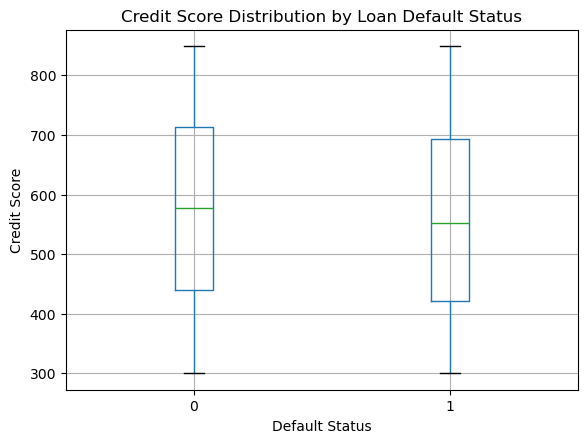

In [6]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="CreditScore",
    by="Default"
)

plt.title("Credit Score Distribution by Loan Default Status")
plt.suptitle("")
plt.xlabel("Default Status")
plt.ylabel("Credit Score")
plt.show()

In [20]:
### Insight

# Borrowers who defaulted had a lower median credit score than borrowers who did not default (553 vs. 577). The distributions overlap substantially, indicating that credit score alone may not be sufficient to distinguish default risk.

In [21]:
df["CreditScoreGroup"] = pd.cut(
    df["CreditScore"],
    bins=[299, 400, 500, 600, 700, 800, 900],
    labels=[
        "300-400",
        "401-500",
        "501-600",
        "601-700",
        "701-800",
        "801-900"
    ]
)

credit_default = (
    df.groupby("CreditScoreGroup", observed=True)["Default"]
      .agg(["count", "sum", "mean"])
)

credit_default["DefaultRate_%"] = credit_default["mean"] * 100

credit_default

,count,sum,mean,DefaultRate_%
CreditScoreGroup,,,,
300-400,47132,6275,0.133137,13.313672
401-500,46375,5666,0.122178,12.217790
501-600,46442,5484,0.118083,11.808277
601-700,46452,5190,0.111728,11.172824
701-800,45946,4777,0.103970,10.396988
801-900,23000,2261,0.098304,9.830435


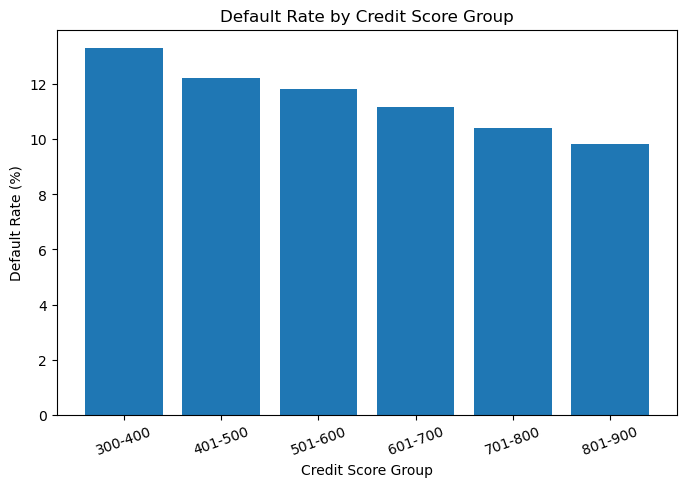

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    credit_default.index,
    credit_default["DefaultRate_%"]
)

plt.title("Default Rate by Credit Score Group")
plt.xlabel("Credit Score Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [8]:
df.groupby("Default")["Income"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,83899.165995,38498.801232,15000.0,50994.0,84237.5,117186.75,149999.0
1,29653.0,71844.722659,40785.099507,15004.0,34022.0,66566.0,106895.00,149995.0


<Figure size 800x500 with 0 Axes>

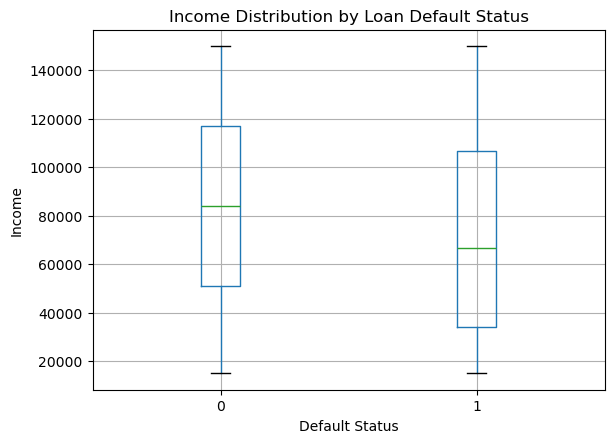

In [9]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="Income",
    by="Default"
)

plt.title("Income Distribution by Loan Default Status")
plt.suptitle("")
plt.xlabel("Default Status")
plt.ylabel("Income")
plt.show()

In [ ]:
# Insight
# Borrowers who defaulted generally had lower income than borrowers who did not default. The difference is particularly noticeable in the median income.

In [10]:
df.groupby("Default")["LoanAmount"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,125353.656017,70708.101479,5001.0,63889.25,124236.0,186177.75,249999.0
1,29653.0,144515.311469,69547.822943,5000.0,88085.00,152672.0,205468.00,249993.0


<Figure size 800x500 with 0 Axes>

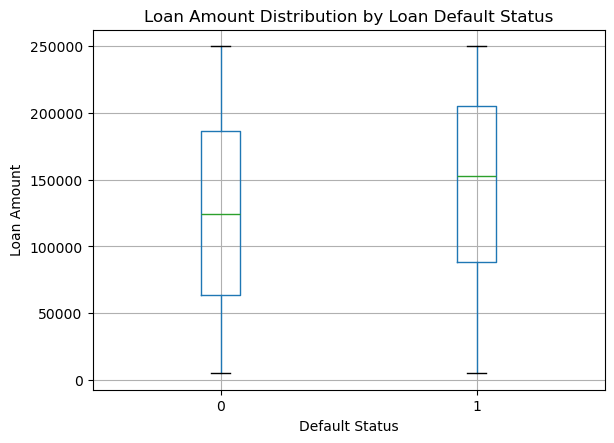

In [11]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="LoanAmount",
    by="Default"
)

plt.title("Loan Amount Distribution by Loan Default Status")
plt.suptitle("")
plt.xlabel("Default Status")
plt.ylabel("Loan Amount")
plt.show()

In [ ]:
### Insight

##Default rates increase across the loan amount groups. The observed default rate rises from approximately 8.6% for loans below 50K to approximately 15.8% for loans between 200K and 250K.

## This suggests that higher loan amounts may be associated with greater default risk. However, this relationship should not be interpreted as causation, and other borrower characteristics may also influence default.

In [12]:
df["LoanAmountGroup"] = pd.cut(
    df["LoanAmount"],
    bins=[0, 50000, 100000, 150000, 200000, 250000],
    labels=["0-50K", "50K-100K", "100K-150K", "150K-200K", "200K-250K"]
)

loan_amount_default = (
    df.groupby("LoanAmountGroup", observed=True)["Default"]
      .agg(["count", "sum", "mean"])
)

loan_amount_default["DefaultRate_%"] = loan_amount_default["mean"] * 100

loan_amount_default

,count,sum,mean,DefaultRate_%
LoanAmountGroup,,,,
0-50K,47091,3797,0.080631,8.063112
50K-100K,51977,4906,0.094388,9.438790
100K-150K,51879,5790,0.111606,11.160585
150K-200K,51981,6885,0.132452,13.245224
200K-250K,52419,8275,0.157863,15.786261


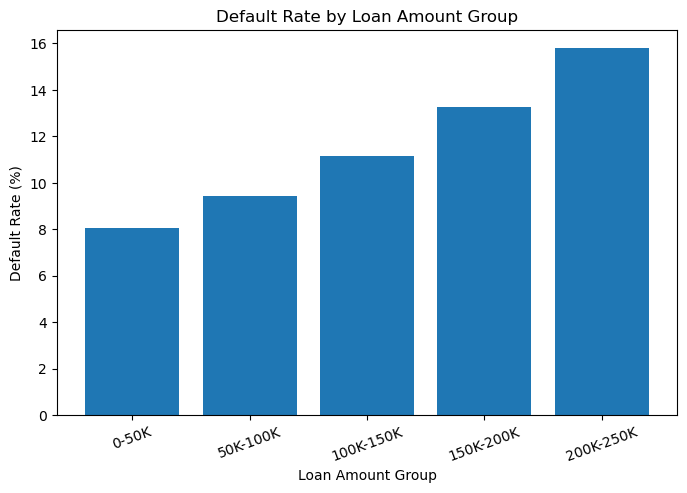

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(
    loan_amount_default.index,
    loan_amount_default["DefaultRate_%"]
)

plt.title("Default Rate by Loan Amount Group")
plt.xlabel("Loan Amount Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [15]:
## DTIRatio vs Default
df.groupby("Default")["DTIRatio"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,0.498602,0.231099,0.1,0.30,0.50,0.70,0.9
1,29653.0,0.512467,0.229160,0.1,0.32,0.52,0.71,0.9


<Figure size 800x500 with 0 Axes>

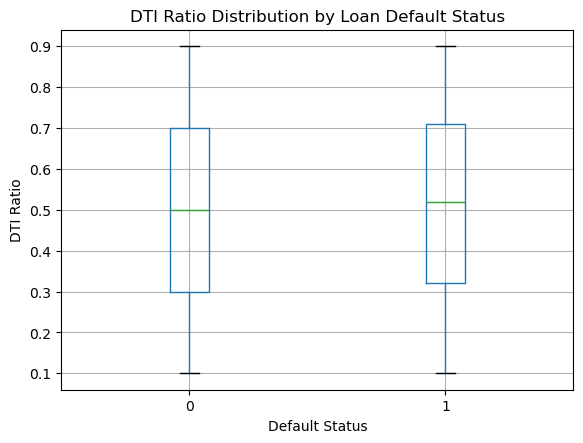

In [16]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="DTIRatio",
    by="Default"
)

plt.title("DTI Ratio Distribution by Loan Default Status")
plt.suptitle("")
plt.xlabel("Default Status")
plt.ylabel("DTI Ratio")
plt.show()

In [17]:
df["DTIGroup"] = pd.cut(
    df["DTIRatio"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]
)

dti_default = (
    df.groupby("DTIGroup", observed=True)["Default"]
      .agg(["count", "sum", "mean"])
)

dti_default["DefaultRate_%"] = dti_default["mean"] * 100

dti_default

,count,sum,mean,DefaultRate_%
DTIGroup,,,,
0.0-0.2,33513,3473,0.103631,10.363143
0.2-0.4,63856,7129,0.111642,11.164182
0.4-0.6,63644,7525,0.118236,11.823581
0.6-0.8,63979,7830,0.122384,12.238391
0.8-1.0,30355,3696,0.121759,12.175918


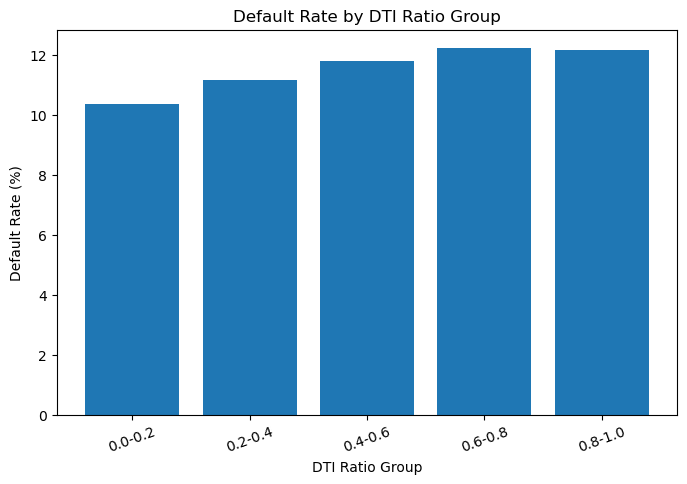

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    dti_default.index,
    dti_default["DefaultRate_%"]
)

plt.title("Default Rate by DTI Ratio Group")
plt.xlabel("DTI Ratio Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [23]:
### Insight

## The observed default rate generally increases as the Debt-to-Income (DTI) ratio increases. Borrowers in the lower DTI range have lower default rates, while borrowers with higher DTI ratios show somewhat higher default rates.

## This suggests that higher debt burden relative to income may be associated with increased loan default risk. However, the relationship is relatively moderate, so DTI should be considered together with other borrower and loan characteristics.

In [26]:
#Interest Rate vs Default

df.groupby("Default")["InterestRate"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,13.176994,6.612265,2.0,7.45,12.99,18.85,25.0
1,29653.0,15.896227,6.320304,2.0,11.06,16.93,21.36,25.0


<Figure size 800x500 with 0 Axes>

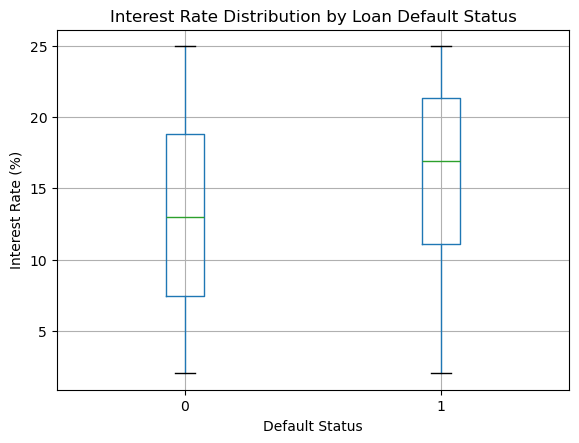

In [27]:
# Interest Rate Box Plot

plt.figure(figsize=(8, 5))

df.boxplot(
    column="InterestRate",
    by="Default"
)

plt.title("Interest Rate Distribution by Loan Default Status")
plt.suptitle("")
plt.xlabel("Default Status")
plt.ylabel("Interest Rate (%)")
plt.show()

In [28]:
# Create Interest Rate groups

df["InterestRateGroup"] = pd.cut(
    df["InterestRate"],
    bins=[1, 5, 10, 15, 20, 25],
    labels=[
        "2-5%",
        "5-10%",
        "10-15%",
        "15-20%",
        "20-25%"
    ]
)

interest_default = (
    df.groupby("InterestRateGroup", observed=True)["Default"]
      .agg(["count", "sum", "mean"])
)

interest_default["DefaultRate_%"] = interest_default["mean"] * 100

interest_default

,count,sum,mean,DefaultRate_%
InterestRateGroup,,,,
2-5%,33292,2005,0.060225,6.022468
5-10%,55659,4278,0.076861,7.686089
10-15%,55934,5899,0.105464,10.546358
15-20%,54978,7584,0.137946,13.794609
20-25%,55484,9887,0.178196,17.819552


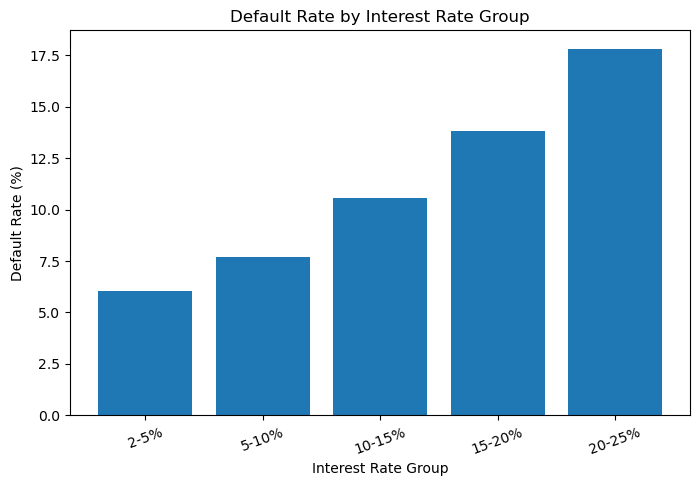

In [30]:
# 4. Create the default-rate chart

plt.figure(figsize=(8, 5))

plt.bar(
    interest_default.index,
    interest_default["DefaultRate_%"]
)

plt.title("Default Rate by Interest Rate Group")
plt.xlabel("Interest Rate Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [31]:
# 1 Age vs Default

df.groupby("Default")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,44.409962,14.889574,18.0,32.0,45.0,57.0,69.0
1,29653.0,36.559539,13.897468,18.0,25.0,34.0,47.0,69.0


<Figure size 800x500 with 0 Axes>

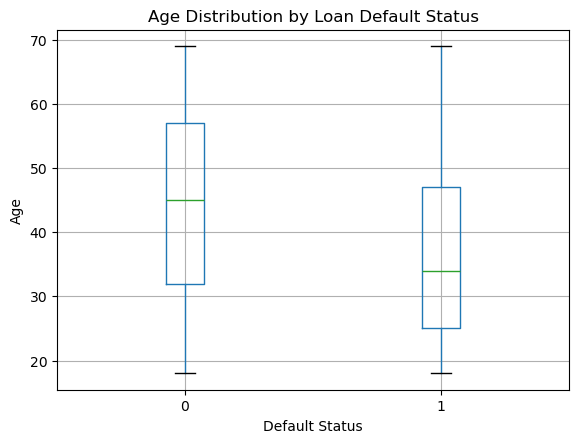

In [32]:
# 2. Age box plot

plt.figure(figsize=(8, 5))

df.boxplot(
    column="Age",
    by="Default"
)

plt.title("Age Distribution by Loan Default Status")
plt.suptitle("")
plt.xlabel("Default Status")
plt.ylabel("Age")
plt.show()

In [33]:
# 3. Create Age groups

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 65, 70],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66-70"
    ]
)

age_default = (
    df.groupby("AgeGroup", observed=True)["Default"]
      .agg(["count", "sum", "mean"])
)

age_default["DefaultRate_%"] = age_default["mean"] * 100

age_default

,count,sum,mean,DefaultRate_%
AgeGroup,,,,
18-25,39016,8100,0.207607,20.760714
26-35,49408,7944,0.160784,16.078368
36-45,49220,5684,0.115482,11.548151
46-55,49148,4153,0.084500,8.449988
56-65,49063,2875,0.058598,5.859813
66-70,19492,897,0.046019,4.601888


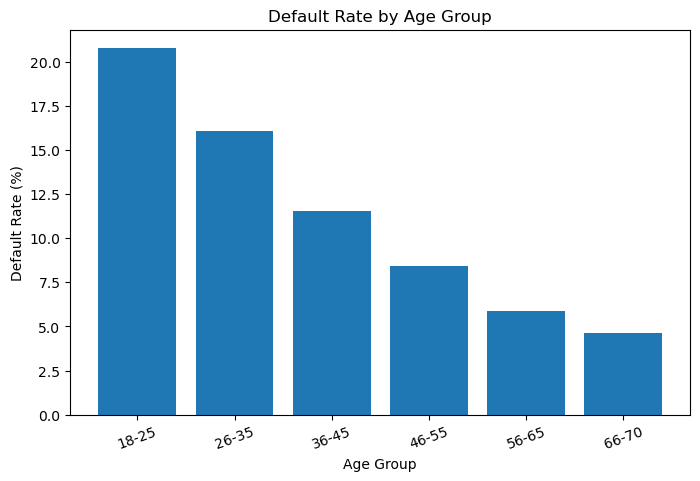

In [34]:
# 4. Default-rate chart
plt.figure(figsize=(8, 5))

plt.bar(
    age_default.index,
    age_default["DefaultRate_%"]
)

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [35]:
# Loan Term vs Default
df.groupby("Default")["LoanTerm"].describe()


,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,36.022544,16.966374,12.0,24.0,36.0,48.0,60.0
1,29653.0,36.051394,16.992077,12.0,24.0,36.0,48.0,60.0


<Figure size 800x500 with 0 Axes>

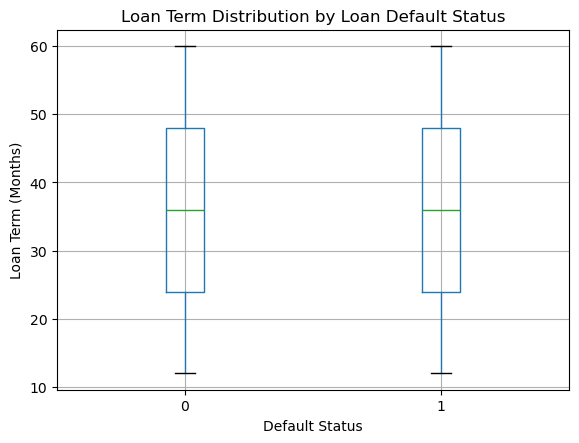

In [36]:
# Step 2 — Loan Term box plot

plt.figure(figsize=(8, 5))

df.boxplot(
    column="LoanTerm",
    by="Default"
)

plt.title("Loan Term Distribution by Loan Default Status")
plt.suptitle("")
plt.xlabel("Default Status")
plt.ylabel("Loan Term (Months)")
plt.show()

In [37]:
# Step 3 — Create Loan Term groups

df["LoanTermGroup"] = pd.cut(
    df["LoanTerm"],
    bins=[11, 24, 36, 48, 60],
    labels=[
        "12-24",
        "25-36",
        "37-48",
        "49-60"
    ]
)

loan_term_default = (
    df.groupby("LoanTermGroup", observed=True)["Default"]
      .agg(["count", "sum", "mean"])
)

loan_term_default["DefaultRate_%"] = (
    loan_term_default["mean"] * 100
)

loan_term_default

,count,sum,mean,DefaultRate_%
LoanTermGroup,,,,
12-24,101966,11841,0.116127,11.612694
25-36,51061,5907,0.115685,11.568516
37-48,51166,5922,0.115741,11.574092
49-60,51154,5983,0.116961,11.696055


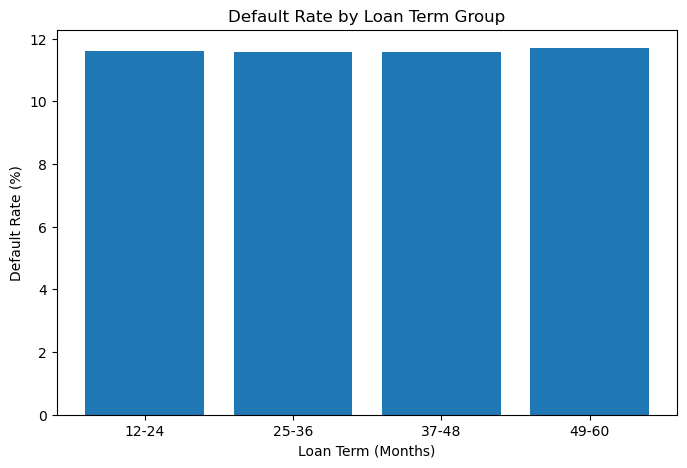

In [39]:
# Step 4 — Default-rate chart

plt.figure(figsize=(8, 5))

plt.bar(
    loan_term_default.index,
    loan_term_default["DefaultRate_%"]
)

plt.title("Default Rate by Loan Term Group")
plt.xlabel("Loan Term (Months)")
plt.ylabel("Default Rate (%)")
plt.show()

In [40]:
# Months Employed vs Default

df.groupby("Default")["MonthsEmployed"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,60.764721,34.556394,0.0,31.0,61.0,91.0,119.0
1,29653.0,50.235457,33.882499,0.0,21.0,46.0,78.0,119.0


<Figure size 800x500 with 0 Axes>

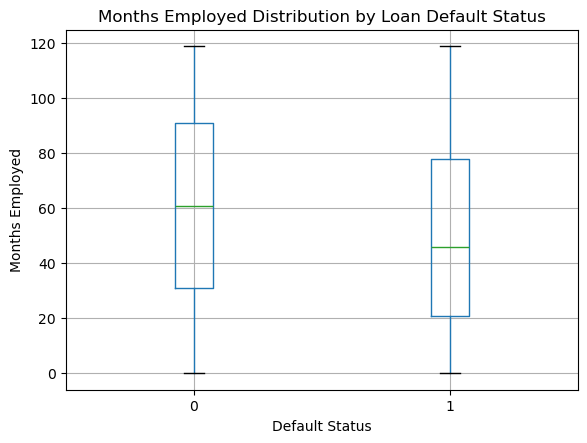

In [41]:
# 2. Box plot
plt.figure(figsize=(8, 5))

df.boxplot(
    column="MonthsEmployed",
    by="Default"
)

plt.title("Months Employed Distribution by Loan Default Status")
plt.suptitle("")
plt.xlabel("Default Status")
plt.ylabel("Months Employed")
plt.show()


In [42]:
# 3. Create employment-duration groups

df["MonthsEmployedGroup"] = pd.cut(
    df["MonthsEmployed"],
    bins=[-1, 24, 48, 72, 96, 120],
    labels=[
        "0-24",
        "25-48",
        "49-72",
        "73-96",
        "97-120"
    ]
)

months_employed_default = (
    df.groupby("MonthsEmployedGroup", observed=True)["Default"]
      .agg(["count", "sum", "mean"])
)

months_employed_default["DefaultRate_%"] = (
    months_employed_default["mean"] * 100
)

months_employed_default

,count,sum,mean,DefaultRate_%
MonthsEmployedGroup,,,,
0-24,52985,8603,0.162367,16.236671
25-48,51149,6916,0.135213,13.521281
49-72,51054,5646,0.110589,11.058879
73-96,51130,4756,0.093018,9.301780
97-120,49029,3732,0.076118,7.611822


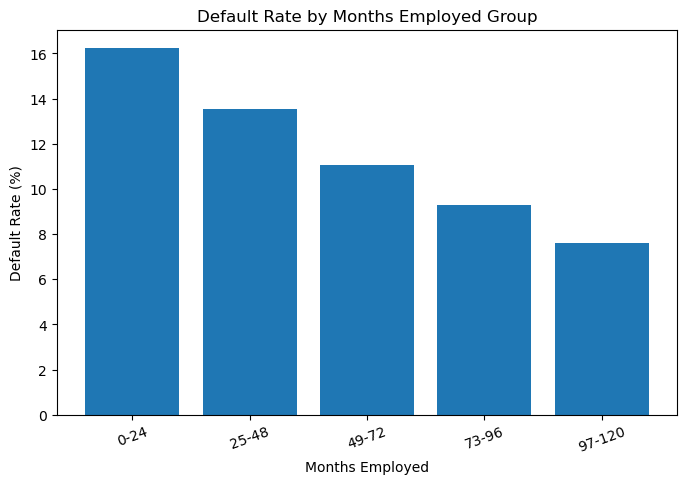

In [43]:
# 4. Default-rate chart

plt.figure(figsize=(8, 5))

plt.bar(
    months_employed_default.index,
    months_employed_default["DefaultRate_%"]
)

plt.title("Default Rate by Months Employed Group")
plt.xlabel("Months Employed")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [44]:
# Employment Type vs Default

employment_default = (
    df.groupby("EmploymentType")["Default"]
      .agg(["count", "sum", "mean"])
)

employment_default["DefaultRate_%"] = (
    employment_default["mean"] * 100
)

employment_default

,count,sum,mean,DefaultRate_%
EmploymentType,,,,
Full-time,63656,6024,0.094634,9.463366
Part-time,64161,7677,0.119652,11.965213
Self-employed,63706,7302,0.114620,11.462029
Unemployed,63824,8650,0.135529,13.552895


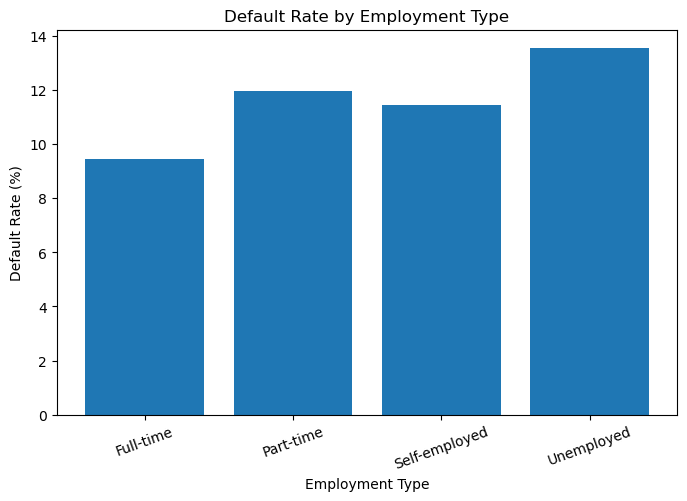

In [45]:
# Step 2 — Plot

plt.figure(figsize=(8, 5))

plt.bar(
    employment_default.index,
    employment_default["DefaultRate_%"]
)

plt.title("Default Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [46]:
# 🔟 Education vs Default
education_default = (
    df.groupby("Education")["Default"]
      .agg(["count", "sum", "mean"])
)

education_default["DefaultRate_%"] = (
    education_default["mean"] * 100
)

education_default

,count,sum,mean,DefaultRate_%
Education,,,,
Bachelor's,64366,7789,0.121011,12.101109
High School,63903,8230,0.128789,12.878895
Master's,63541,6908,0.108717,10.871721
PhD,63537,6726,0.105860,10.585958


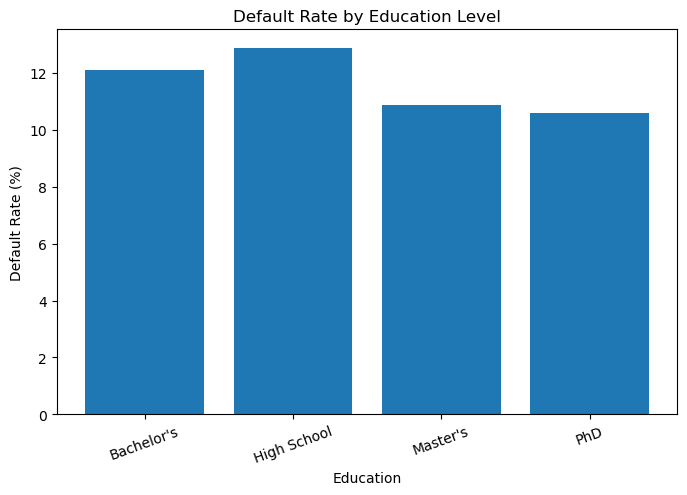

In [48]:
# Chart:

plt.figure(figsize=(8, 5))

plt.bar(
    education_default.index,
    education_default["DefaultRate_%"]
)

plt.title("Default Rate by Education Level")
plt.xlabel("Education")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [49]:
# 1️⃣1️⃣ Loan Purpose vs Default
loan_purpose_default = (
    df.groupby("LoanPurpose")["Default"]
      .agg(["count", "sum", "mean"])
)

loan_purpose_default["DefaultRate_%"] = (
    loan_purpose_default["mean"] * 100
)

loan_purpose_default

,count,sum,mean,DefaultRate_%
LoanPurpose,,,,
Auto,50844,6041,0.118814,11.881441
Business,51298,6323,0.123260,12.326017
Education,51005,6038,0.118381,11.838055
Home,51286,5249,0.102348,10.234762
Other,50914,6002,0.117885,11.788506


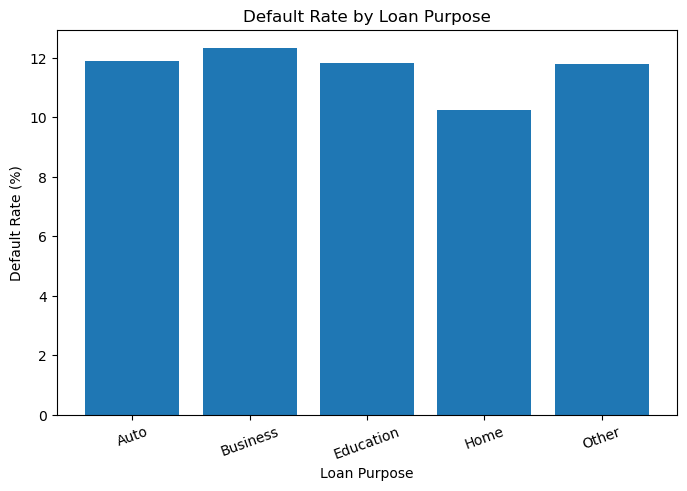

In [50]:
plt.figure(figsize=(8, 5))

plt.bar(
    loan_purpose_default.index,
    loan_purpose_default["DefaultRate_%"]
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [51]:
# 1️⃣2️⃣ Mortgage Status vs Default

mortgage_default = (
    df.groupby("HasMortgage")["Default"]
      .agg(["count", "sum", "mean"])
)

mortgage_default["DefaultRate_%"] = (
    mortgage_default["mean"] * 100
)

mortgage_default

,count,sum,mean,DefaultRate_%
HasMortgage,,,,
No,127670,15761,0.123451,12.345108
Yes,127677,13892,0.108806,10.880581


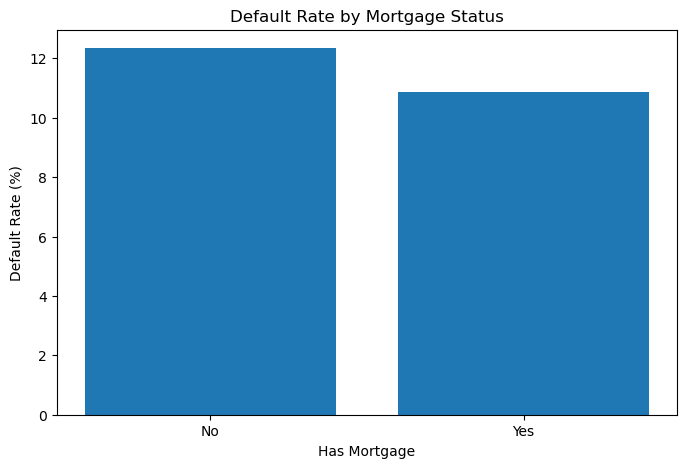

In [52]:
plt.figure(figsize=(8, 5))

plt.bar(
    mortgage_default.index,
    mortgage_default["DefaultRate_%"]
)

plt.title("Default Rate by Mortgage Status")
plt.xlabel("Has Mortgage")
plt.ylabel("Default Rate (%)")
plt.show()

In [53]:
# 13 NumCreditLines vs Default.

df.groupby("Default")["NumCreditLines"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,2.489566,1.116350,1.0,1.0,2.0,3.0,4.0
1,29653.0,2.588338,1.118258,1.0,2.0,3.0,4.0,4.0


In [54]:
# Create credit-line groups
credit_lines_default = (
    df.groupby("NumCreditLines")["Default"]
      .agg(["count", "sum", "mean"])
)

credit_lines_default["DefaultRate_%"] = (
    credit_lines_default["mean"] * 100
)

credit_lines_default

,count,sum,mean,DefaultRate_%
NumCreditLines,,,,
1,63554,6688,0.105233,10.523334
2,64130,7092,0.110588,11.058787
3,63834,7612,0.119247,11.924680
4,63829,8261,0.129424,12.942393


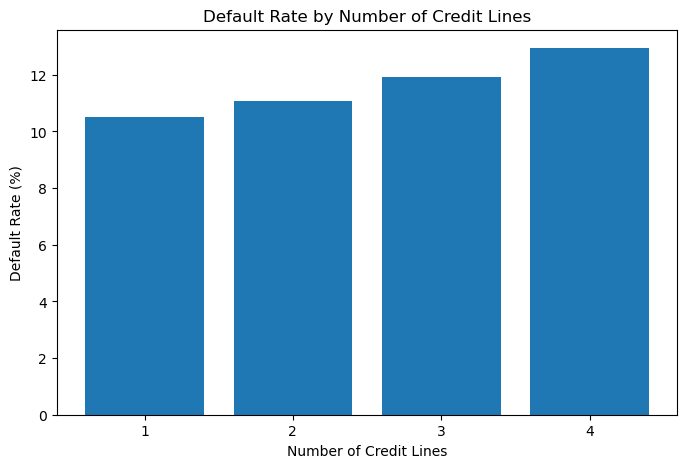

In [55]:
# Plot default rate
plt.figure(figsize=(8, 5))

plt.bar(
    credit_lines_default.index.astype(str),
    credit_lines_default["DefaultRate_%"]
)

plt.title("Default Rate by Number of Credit Lines")
plt.xlabel("Number of Credit Lines")
plt.ylabel("Default Rate (%)")
plt.show()

In [56]:
# 14  MaritalStatus vs Default
## Step 1 — Default-rate table

marital_default = (
    df.groupby("MaritalStatus")["Default"]
      .agg(["count", "sum", "mean"])
)

marital_default["DefaultRate_%"] = (
    marital_default["mean"] * 100
)

marital_default

,count,sum,mean,DefaultRate_%
MaritalStatus,,,,
Divorced,85033,10657,0.125328,12.532781
Married,85302,8869,0.103972,10.397177
Single,85012,10127,0.119124,11.912436


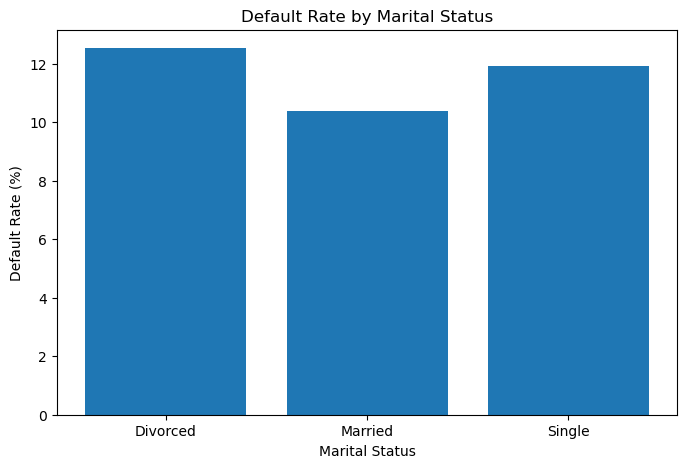

In [58]:
# Step 2 — Chart
plt.figure(figsize=(8, 5))

plt.bar(
    marital_default.index,
    marital_default["DefaultRate_%"]
)

plt.title("Default Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Default Rate (%)")
plt.show()


In [59]:
## 15. HasDependents vs Default
# Step 1 — Default-rate table
dependents_default = (
    df.groupby("HasDependents")["Default"]
      .agg(["count", "sum", "mean"])
)

dependents_default["DefaultRate_%"] = (
    dependents_default["mean"] * 100
)

dependents_default

,count,sum,mean,DefaultRate_%
HasDependents,,,,
No,127605,16237,0.127244,12.724423
Yes,127742,13416,0.105024,10.502419


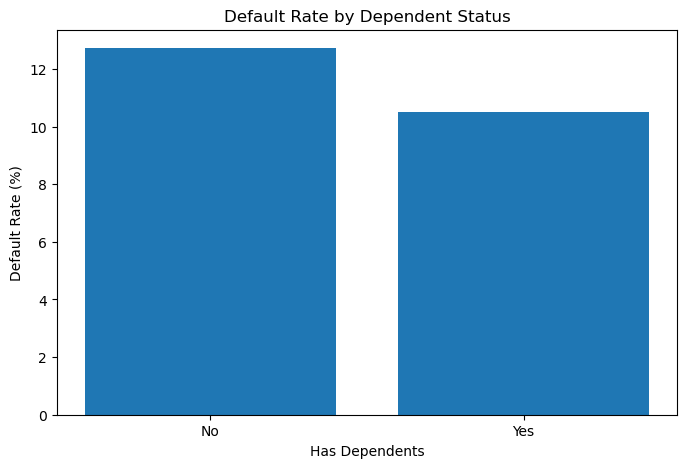

In [60]:
# Step 2 — Chart
plt.figure(figsize=(8, 5))

plt.bar(
    dependents_default.index,
    dependents_default["DefaultRate_%"]
)

plt.title("Default Rate by Dependent Status")
plt.xlabel("Has Dependents")
plt.ylabel("Default Rate (%)")
plt.show()

In [61]:
# 16. HasCoSigner vs Default
# Step 1 — Default-rate table
cosigner_default = (
    df.groupby("HasCoSigner")["Default"]
      .agg(["count", "sum", "mean"])
)

cosigner_default["DefaultRate_%"] = (
    cosigner_default["mean"] * 100
)

cosigner_default

,count,sum,mean,DefaultRate_%
HasCoSigner,,,,
No,127646,16423,0.128661,12.866051
Yes,127701,13230,0.103601,10.360138


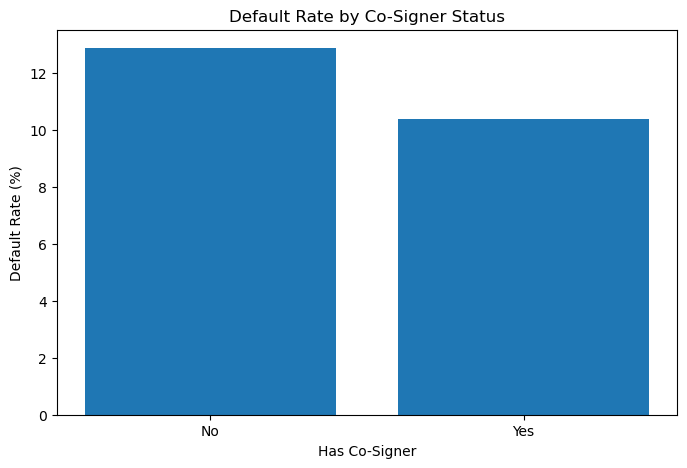

In [62]:
# Step 2 — Chart
plt.figure(figsize=(8, 5))

plt.bar(
    cosigner_default.index,
    cosigner_default["DefaultRate_%"]
)

plt.title("Default Rate by Co-Signer Status")
plt.xlabel("Has Co-Signer")
plt.ylabel("Default Rate (%)")
plt.show()

In [63]:
# 17. Loan Date vs Default
# Step 1 — Convert Loan Date
df["LoanDate"] = pd.to_datetime(
    df["Loan Date (DD/MM/YYYY)"],
    format="%m/%d/%Y",
    errors="coerce"
)

df["LoanDate"].head()

0   2018-10-15
1   2016-03-25
2   2013-11-11
3   2017-06-22
4   2014-06-09
Name: LoanDate, dtype: datetime64[ns]

In [64]:
df["LoanDate"].isna().sum()

np.int64(0)

In [65]:
df["LoanYear"] = df["LoanDate"].dt.year

loan_year_default = (
    df.groupby("LoanYear")["Default"]
      .agg(["count", "sum", "mean"])
)

loan_year_default["DefaultRate_%"] = (
    loan_year_default["mean"] * 100
)

loan_year_default

,count,sum,mean,DefaultRate_%
LoanYear,,,,
2013,42785,4973,0.116232,11.623232
2014,42122,4845,0.115023,11.502303
2015,42521,4976,0.117025,11.702453
2016,42705,5017,0.117480,11.748039
2017,42377,4875,0.115039,11.503882
2018,42837,4967,0.115951,11.595116


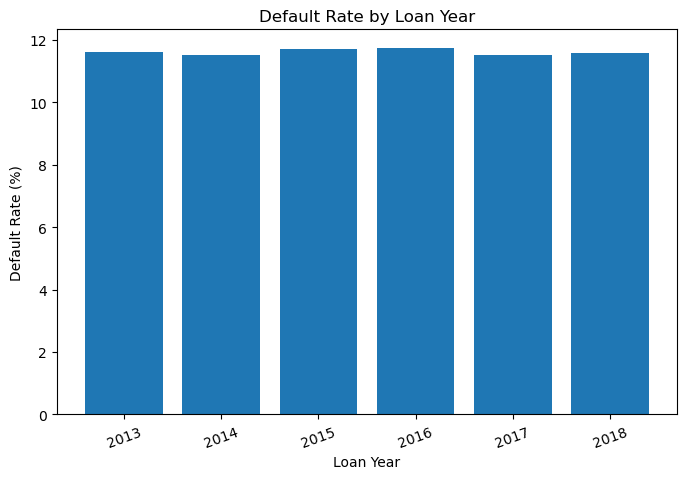

In [66]:
plt.figure(figsize=(8, 5))

plt.bar(
    loan_year_default.index.astype(str),
    loan_year_default["DefaultRate_%"]
)

plt.title("Default Rate by Loan Year")
plt.xlabel("Loan Year")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()